In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [14]:
# 1. Carrega o dataset limpo e padronizado
df = pd.read_csv('../data/processed/dataset_clean.csv')

# 2. Define o Target (Y) para a Regressão
alvo_regressao = 'Total_Amount'
y = df[alvo_regressao]

# 3. Define as variáveis preditoras (X), removendo o alvo da tabela
X = df.drop(columns=[alvo_regressao])

print(f"O modelo de Regressão tentará prever: {alvo_regressao}")
print(f"Quantidade de variáveis (pistas) disponíveis: {X.shape[1]}")

O modelo de Regressão tentará prever: Total_Amount
Quantidade de variáveis (pistas) disponíveis: 53


Colunas que sobraram para o modelo estudar:
['Quantity', 'Shipping_Cost', 'Coupon_Discount', 'Customer_Age', 'Age', 'Pincode', 'Total_Orders', 'Total_Spent', 'Original_Price', 'Discount_Percent', 'Discount_Amount', 'Stock_Quantity', 'Weight_kg', 'Avg_Rating', 'Total_Reviews', 'Payment_Mode_Credit Card', 'Payment_Mode_Debit Card', 'Payment_Mode_UPI', 'Category_Books', 'Category_Electronics', 'Category_Fashion', 'Category_Grocery', 'Category_Home', 'Category_Sports', 'Gender_male', 'Rating_4.0', 'Rating_5.0', 'Rating_Sem_Avaliacao']
--------------------------------------------------
Top 10 variáveis mais importantes para prever o Total_Amount:
            Variavel  Importancia
8     Original_Price     0.762729
0           Quantity     0.196085
9   Discount_Percent     0.036726
10   Discount_Amount     0.001491
2    Coupon_Discount     0.001300
13        Avg_Rating     0.000623
14     Total_Reviews     0.000419
11    Stock_Quantity     0.000322
12         Weight_kg     0.000265
1      Shi

/tmp/ipykernel_9942/327092048.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabela_importancia.head(10), x='Importancia', y='Variavel', palette='viridis')


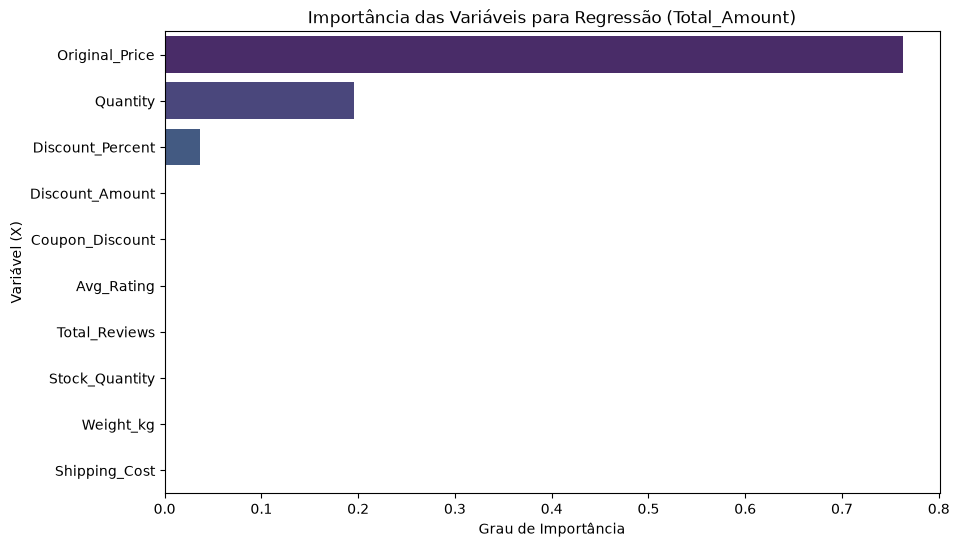

In [11]:
# 3. Limpeza do X: Remove o Target e colunas de identificação inúteis para a previsão
colunas_para_remover = [alvo_regressao, 'Order_ID', 'Customer_ID', 'Product_ID', 'Order_Value', 'Unit_Price'] 
X = df.drop(columns=colunas_para_remover, errors='ignore')

# BLINDAGEM EXTRA: Remove à força qualquer coluna que ainda seja texto (object) 
# Isso garante que só fiquem números, evitando o ValueError.
X = X.select_dtypes(exclude=['object'])

print("Colunas que sobraram para o modelo estudar:")
print(X.columns.tolist())
print("-" * 50)

# 4. Cria e treina o modelo de importância
modelo_importancia = RandomForestRegressor(n_estimators=50, random_state=42)
modelo_importancia.fit(X, y)

# 5. Extrai a nota de importância
importancias = modelo_importancia.feature_importances_
tabela_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 6. Exibe as 10 variáveis mais importantes
print("Top 10 variáveis mais importantes para prever o Total_Amount:")
print(tabela_importancia.head(10))

# 7. Gera o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=tabela_importancia.head(10), x='Importancia', y='Variavel', palette='viridis')
plt.title('Importância das Variáveis para Regressão (Total_Amount)')
plt.xlabel('Grau de Importância')
plt.ylabel('Variável (X)')
plt.savefig('../reports/figures/feature_importance_regression.png', bbox_inches='tight')
plt.show()

In [15]:
# 1. Filtramos o X para manter apenas as 3 variáveis vitais descobertas
features_selecionadas = ['Original_Price', 'Quantity', 'Discount_Percent']
X_final_regressao = X[features_selecionadas]

# 2. Divisão da Base: 80% para treinar o algoritmo, 20% para a prova real (teste)
X_train, X_test, y_train, y_test = train_test_split(X_final_regressao, y, test_size=0.2, random_state=42)

# 3. Construção e Treinamento do Modelo
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

# 4. Avaliação de Desempenho usando a métrica R² (coeficiente de determinação)
previsoes = modelo_regressao.predict(X_test)
acuracia = r2_score(y_test, previsoes)

print(f"Pipeline de Regressão estruturado com sucesso!")
print(f"O modelo consegue prever o valor total da compra com {acuracia * 100:.2f}% de exatidão utilizando apenas as 3 variáveis selecionadas.")

Pipeline de Regressão estruturado com sucesso!
O modelo consegue prever o valor total da compra com 82.76% de exatidão utilizando apenas as 3 variáveis selecionadas.
